# 招聘数据清洗与整理

**处理目标：** 对整合后的招聘数据进行深度清洗和整理

**数据源：** `datas/target/招聘数据_整合_20251014_101650.xlsx`

**输出：** 清洗后的高质量数据集

---

## 处理流程

1. **环境准备与数据加载**
2. **数据概览**
3. **缺失值分析与处理**
4. **重复行检测与处理**
5. **异常值分析与处理**
6. **数据验证与导出**


## 1. 环境准备与数据加载


In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# 设置中文显示（macOS）
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置图表样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 忽略警告
warnings.filterwarnings('ignore')

print("✅ 环境准备完成！")
print(f"📅 清洗开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ 环境准备完成！
📅 清洗开始时间: 2025-10-14 10:47:05


In [2]:
# 这里用的是 SimHei 字体，可以根据自己的需要更改
from wanglaoshi import JupyterFont as JF
JF.matplotlib_font_init()

In [3]:
# 加载数据
file_path = 'datas/target/招聘数据_整合_20251014_101650.xlsx'

print("📂 正在加载数据...")
print("=" * 80)

df = pd.read_excel(file_path)

print(f"✓ 数据加载完成")
print(f"  • 数据形状: {df.shape[0]:,} 行 × {df.shape[1]} 列")
print(f"  • 内存占用: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 保存原始数据的副本
df_original = df.copy()
print(f"  • 已创建原始数据备份")

print("\n" + "=" * 80)


📂 正在加载数据...
✓ 数据加载完成
  • 数据形状: 51,329 行 × 20 列
  • 内存占用: 111.20 MB
  • 已创建原始数据备份



## 2. 数据概览

**目的：** 快速了解数据的基本情况


In [4]:
# 数据概览
print("📊 数据概览")
print("=" * 80)

print(f"\n【基本信息】")
print(f"  行数: {df.shape[0]:,}")
print(f"  列数: {df.shape[1]}")

print(f"\n【前5行数据】")
display(df.head())

print(f"\n【数据类型分布】")
print(df.dtypes.value_counts())

print(f"\n【数据来源分布】")
if '数据来源' in df.columns:
    source_counts = df['数据来源'].value_counts()
    for source, count in source_counts.items():
        print(f"  • {source}: {count:,} 条 ({count/len(df)*100:.1f}%)")

print("\n" + "=" * 80)


📊 数据概览

【基本信息】
  行数: 51,329
  列数: 20

【前5行数据】


,数据来源,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,学历要求,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,平均年薪,所处行业,最低月薪,最高月薪,状态要求,薪资,薪资月
0,营销类,北京,B,趋动科技,NaN,趋动科技,B轮,大专及以上,客户经理,销售经理 金融行业（银行、证券、保险）,全职,职位描述：职位描述： \n1.建立良好的客户关系；与应用需求部门、平台部门、基础架构及采购等...,六险一金，弹性工作，期权激励，绩效奖金,450.0,人工智能服务,25,50,经验5-10年,25k-50k,12.0
1,营销类,上海,B,百融云创,NaN,百融云创保险销售部,上市公司,本科及以上,客户经理,销售经理（上海保险） (MJ000644),全职,职位描述：岗位职责: \n1、独立开展保险行业线业务销售； \n2、挖掘保险公司不同部门的业...,平台稳定，发展空间大,277.5,"科技金融,人工智能服务",15,22,经验5-10年,15k-22k·15薪,15.0
2,营销类,北京,B,中信保诚人寿,2000人以上,中信保诚人寿银保部,上市公司,本科及以上,客户经理,保险公司客户经理,全职,职位描述：一、职责描述： \n1、渠道维护资讯整理：通过与银行渠道相应人员沟通包括影响业务开...,收入高 升职空间大,120.0,金融业,8,12,经验1-3年,8k-12k,12.0
3,营销类,上海,B,中国平安人寿保险股份有限公司上海电话销售中心,2000人以上,中国平安人寿保险股份有限公司上海电话销售中心,上市公司,大专及以上,客户经理,保险顾问,全职,职位描述：岗位职责：\n1.依托公司平台，通过电话、企业微信、网络等远程形式，借助公司提供的...,免费班车+高低温补贴+四大食堂,105.0,金融业,6,8,经验不限,6k-8k·15薪,15.0
4,营销类,北京,B,水滴公司WATERDROP INC.,NaN,水滴公司WATERDROP INC.,上市公司,本科及以上,客户经理,保险产品培训岗,全职,职位描述：保险产品培训岗工作职责：1、与培训部协同，对内对外输出经纪渠道产品（含互联网产品）...,团队氛围好 成长空间大,240.0,科技金融,15,25,经验3-5年,15k-25k,12.0



【数据类型分布】
object     18
float64     2
Name: count, dtype: int64

【数据来源分布】
  • 运营类: 9,091 条 (17.7%)
  • 营销类: 8,702 条 (17.0%)
  • 编程类: 8,629 条 (16.8%)
  • 产品类: 7,026 条 (13.7%)
  • 数据类: 6,583 条 (12.8%)
  • 财会类: 4,851 条 (9.5%)
  • 金融中台: 4,186 条 (8.2%)
  • 管培类: 2,261 条 (4.4%)



## 3. 缺失值分析与处理

**分析目标：**
- 统计各字段的缺失情况
- 分析缺失值的分布模式
- 根据业务逻辑决定处理策略（删除/填充/保留）

**处理策略：**
1. 缺失率 > 80%：考虑删除该字段
2. 缺失率 50%-80%：视业务重要性决定
3. 缺失率 < 50%：可考虑填充或标记


In [5]:
# 缺失值统计
print("🔍 缺失值分析")
print("=" * 80)

# 1. 整体缺失情况
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
missing_ratio = missing_cells / total_cells * 100

print(f"\n【整体缺失情况】")
print(f"  总单元格数: {total_cells:,}")
print(f"  缺失单元格数: {missing_cells:,}")
print(f"  整体缺失率: {missing_ratio:.2f}%")

# 2. 按字段统计缺失值
missing_stats = pd.DataFrame({
    '缺失数量': df.isnull().sum(),
    '缺失比例(%)': (df.isnull().sum() / len(df) * 100).round(2)
})

# 只显示有缺失值的字段
missing_stats = missing_stats[missing_stats['缺失数量'] > 0].sort_values('缺失数量', ascending=False)

print(f"\n【各字段缺失情况】（共 {len(missing_stats)} 个字段有缺失）")
display(missing_stats)

# 3. 按缺失率分类
high_missing = missing_stats[missing_stats['缺失比例(%)'] > 80]
medium_missing = missing_stats[(missing_stats['缺失比例(%)'] >= 50) & (missing_stats['缺失比例(%)'] <= 80)]
low_missing = missing_stats[missing_stats['缺失比例(%)'] < 50]

print(f"\n【缺失率分类】")
print(f"  高缺失率 (>80%): {len(high_missing)} 个字段")
if len(high_missing) > 0:
    print(f"    {', '.join(high_missing.index.tolist())}")
    
print(f"  中等缺失率 (50%-80%): {len(medium_missing)} 个字段")
if len(medium_missing) > 0:
    print(f"    {', '.join(medium_missing.index.tolist())}")
    
print(f"  低缺失率 (<50%): {len(low_missing)} 个字段")

print("\n" + "=" * 80)


🔍 缺失值分析

【整体缺失情况】
  总单元格数: 1,026,580
  缺失单元格数: 70,269
  整体缺失率: 6.84%

【各字段缺失情况】（共 19 个字段有缺失）


,缺失数量,缺失比例(%)
公司规模,9602,18.71
公司阶段,8684,16.92
岗位诱惑,8474,16.51
最高月薪,7613,14.83
所处行业,6216,12.11
岗位类型,6026,11.74
公司分级,5212,10.15
最低月薪,4239,8.26
平均年薪,4043,7.88
薪资月,4030,7.85



【缺失率分类】
  高缺失率 (>80%): 0 个字段
  中等缺失率 (50%-80%): 0 个字段
  低缺失率 (<50%): 19 个字段



📊 缺失值可视化


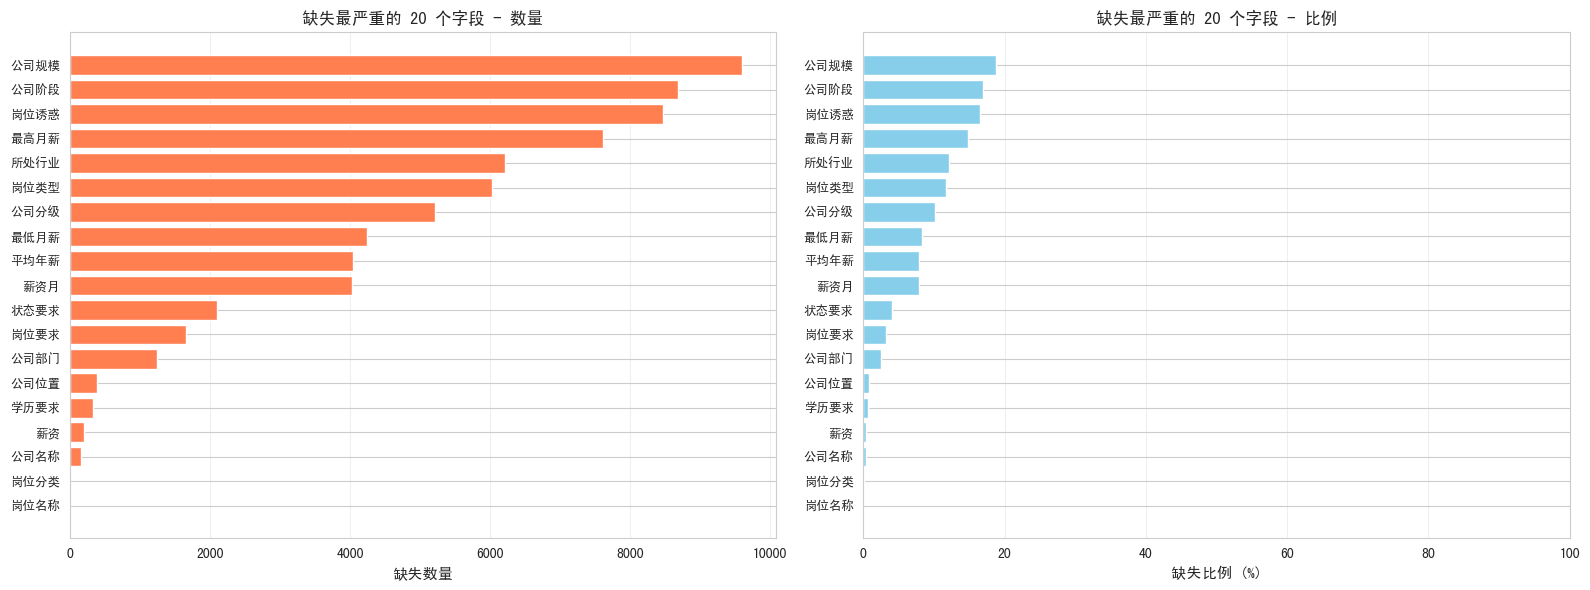

In [6]:
# 缺失值可视化
print("📊 缺失值可视化")
print("=" * 80)

if len(missing_stats) > 0:
    # 只显示缺失最严重的前20个字段
    top_missing = missing_stats.head(20)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左图：缺失数量
    ax1.barh(range(len(top_missing)), top_missing['缺失数量'], color='coral')
    ax1.set_yticks(range(len(top_missing)))
    ax1.set_yticklabels(top_missing.index, fontsize=9)
    ax1.set_xlabel('缺失数量', fontsize=11)
    ax1.set_title('缺失最严重的 20 个字段 - 数量', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # 右图：缺失比例
    ax2.barh(range(len(top_missing)), top_missing['缺失比例(%)'], color='skyblue')
    ax2.set_yticks(range(len(top_missing)))
    ax2.set_yticklabels(top_missing.index, fontsize=9)
    ax2.set_xlabel('缺失比例 (%)', fontsize=11)
    ax2.set_title('缺失最严重的 20 个字段 - 比例', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 100)
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ 数据完整，无缺失值！")

print("=" * 80)


## 4. 重复行检测与处理

**分析目标：**
- 检测完全重复的记录
- 检测基于关键字段的重复（如职位名称+公司名称）
- 决定保留策略

**处理策略：**
1. 完全重复：删除
2. 关键字段重复：保留第一条或最新的记录


In [8]:
# 重复行检测（改进版）
print("🔍 重复行检测")
print("=" * 80)

# 1. 完全重复检测 - 显示所有重复组
duplicates_all = df.duplicated(keep=False)  # keep=False 会标记所有重复行（包括第一次出现的）
dup_count_all = df.duplicated(keep='first').sum()  # 只计算重复的行数（不包括第一次）

print(f"\n【完全重复检测】")
print(f"  重复行数: {dup_count_all:,} (不包括每组的第一条)")
print(f"  涉及的总行数: {duplicates_all.sum():,} (包括每组的第一条)")
print(f"  重复比例: {(dup_count_all/len(df)*100):.2f}%")

if dup_count_all > 0:
    # 获取所有重复的行
    dup_rows = df[duplicates_all].copy()
    
    # 添加一个分组ID，相同的记录会有相同的ID
    dup_rows['重复组ID'] = dup_rows.groupby(list(df.columns)).ngroup()
    
    # 显示前几个重复组
    print(f"\n  查看前3个重复组的记录:")
    for group_id in dup_rows['重复组ID'].unique()[:3]:
        group_data = dup_rows[dup_rows['重复组ID'] == group_id]
        print(f"\n  === 重复组 {group_id + 1}（共 {len(group_data)} 条相同记录）===")
        display(group_data.drop(columns=['重复组ID']).head())

print("\n" + "=" * 80)

🔍 重复行检测

【完全重复检测】
  重复行数: 5,459 (不包括每组的第一条)
  涉及的总行数: 8,662 (包括每组的第一条)
  重复比例: 10.64%

  查看前3个重复组的记录:

  === 重复组 1800.0（共 2 条相同记录）===


,数据来源,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,学历要求,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,平均年薪,所处行业,最低月薪,最高月薪,状态要求,薪资,薪资月
422,营销类,上海,B,国康,150-500人,国康,C轮,本科及以上,客户经理,大客户经理管培生[新洲],全职,职位描述：公司介绍：国康，专注大健康行业17年，被誉为健康管理行业的“黄埔军校”。B端业务面...,良好的培训体系+完善的晋级渠道,224.0,医疗｜保健｜美容,12,20,在校应届,12k-20k·14薪,14.0
1502,营销类,上海,B,国康,150-500人,国康,C轮,本科及以上,客户经理,大客户经理管培生[新洲],全职,职位描述：公司介绍：国康，专注大健康行业17年，被誉为健康管理行业的“黄埔军校”。B端业务面...,良好的培训体系+完善的晋级渠道,224.0,医疗｜保健｜美容,12,20,在校应届,12k-20k·14薪,14.0



  === 重复组 1803.0（共 2 条相同记录）===


,数据来源,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,学历要求,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,平均年薪,所处行业,最低月薪,最高月薪,状态要求,薪资,薪资月
441,营销类,上海,B,泛微,2000人以上,泛微营销服务部,上市公司,本科及以上,客户经理,大客户销售[浦江],全职,职位描述：岗位职责： \n1、负责公司云OA产品的销售，根据公司各个渠道的线索数据来源，通过...,上市公司 自主销售 合伙人 高提成 一次三餐,168.0,软件服务｜咨询,10,18,在校应届,10k-18k,12.0
1505,营销类,上海,B,泛微,2000人以上,泛微营销服务部,上市公司,本科及以上,客户经理,大客户销售[浦江],全职,职位描述：岗位职责： \n1、负责公司云OA产品的销售，根据公司各个渠道的线索数据来源，通过...,上市公司 自主销售 合伙人 高提成 一次三餐,168.0,软件服务｜咨询,10,18,在校应届,10k-18k,12.0



  === 重复组 nan（共 0 条相同记录）===


,数据来源,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,学历要求,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,平均年薪,所处行业,最低月薪,最高月薪,状态要求,薪资,薪资月


In [11]:
# 重复行检测
print("🔍 重复行检测")
print("=" * 80)

# 1. 完全重复检测
duplicates_all = df.duplicated()
dup_count_all = duplicates_all.sum()

print(f"\n【完全重复检测】")
print(f"  重复行数: {dup_count_all:,}")
print(f"  重复比例: {(dup_count_all/len(df)*100):.2f}%")

if dup_count_all > 0:
    print(f"\n  查看部分重复记录:")
    dup_records = df[duplicates_all].head(5)
    display(dup_records)


🔍 重复行检测

【完全重复检测】
  重复行数: 5,459
  重复比例: 10.64%

  查看部分重复记录:


,数据来源,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,学历要求,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,平均年薪,所处行业,最低月薪,最高月薪,状态要求,薪资,薪资月
1502,营销类,上海,B,国康,150-500人,国康,C轮,本科及以上,客户经理,大客户经理管培生[新洲],全职,职位描述：公司介绍：国康，专注大健康行业17年，被誉为健康管理行业的“黄埔军校”。B端业务面...,良好的培训体系+完善的晋级渠道,224.0,医疗｜保健｜美容,12,20,在校应届,12k-20k·14薪,14.0
1503,营销类,上海,B,德佑房地产经纪有限公司,NaN,德佑房地产经纪有限公司,D轮及以上,本科及以上,客户经理,储备干部 管培生 大客户经理[闵行区],全职,职位描述：也许我们给的薪水不是最高的！ \n但是我们给大学生的成长，一家上市企业，头部企业，...,总部直招储备干部 管培生 一年有晋升,108.0,"移动互联网,消费生活",8,10,在校应届,8k-10k,12.0
1505,营销类,上海,B,泛微,2000人以上,泛微营销服务部,上市公司,本科及以上,客户经理,大客户销售[浦江],全职,职位描述：岗位职责： \n1、负责公司云OA产品的销售，根据公司各个渠道的线索数据来源，通过...,上市公司 自主销售 合伙人 高提成 一次三餐,168.0,软件服务｜咨询,10,18,在校应届,10k-18k,12.0
1506,营销类,上海,C,平安租赁,500-2000人,平安租赁平安商业保理公司,不需要融资,本科及以上,客户经理,储备客户经理-商业保理（2019届校招）[洋泾],全职,职位描述：\n工作地点：上海、北京、哈尔滨、青岛、南京\n\n工作职责：\n\n\n 协助推...,500强企业，福利好，大咖多,108.0,金融业,8,10,在校应届,8k-10k,12.0
1508,营销类,上海,B,平安金服,2000人以上,平安金服平安金服,上市公司,本科及以上,客户经理,12516S-金融客户经理[浦东新区],全职,职位描述：工作职责 \n承接客户在网络和电话端的金融贷款产品咨询、业务办理咨询，面向小微企业...,"五险一金,绩效奖金,股票期权,高温补贴",108.0,科技金融,8,10,在校应届,8k-10k,12.0


In [19]:
# 2. 基于关键字段的重复检测（改进版 - 分组显示）
key_columns = []
for col in df.columns:
    if any(keyword in col for keyword in ['职位', '岗位', '公司', '企业']):
        key_columns.append(col)

if len(key_columns) > 0:
    print(f"\n【基于关键字段的重复检测】")
    print(f"  关键字段: {', '.join(key_columns)}")
    
    # 标记所有重复行（包括第一次出现的）
    duplicates_key_all = df.duplicated(subset=key_columns, keep=False)
    # 只标记后续重复的行（不包括第一次）
    duplicates_key = df.duplicated(subset=key_columns, keep='first')
    dup_count_key = duplicates_key.sum()
    
    print(f"  重复行数: {dup_count_key:,} (不包括每组的第一条)")
    print(f"  涉及的总行数: {duplicates_key_all.sum():,} (包括每组的第一条)")
    print(f"  重复比例: {(dup_count_key/len(df)*100):.2f}%")
    
    if dup_count_key > 0:
        # 获取所有重复的行
        dup_rows = df[duplicates_key_all].copy()
        
        # 创建分组标识：基于关键字段的值组合
        dup_rows['重复组'] = dup_rows.groupby(key_columns).ngroup()
        
        # 统计每组的数量
        group_counts = dup_rows.groupby('重复组').size().sort_values(ascending=False)
        
        print(f"\n  共发现 {len(group_counts)} 个重复组")
        print(f"  最大重复组有 {group_counts.max()} 条记录")
        
        # 显示前5个重复组
        print(f"\n  === 显示前5个重复组 ===")
        for idx, (group_id, count) in enumerate(group_counts.head(5).items(), 1):
            group_data = dup_rows[dup_rows['重复组'] == group_id]
            
            print(f"\n  【重复组 {idx}】共 {count} 条记录")
            print(f"  关键字段值: ", end="")
            for col in key_columns:
                print(f"{col}={group_data[col].iloc[0]}, ", end="")
            print()
            
            # 显示这组的所有记录（选择显示的列）
            display_cols = key_columns + ['数据来源']
            # 如果有其他重要字段，也可以加上，比如薪资、学历等
            for col in ['薪资', '学历', '经验', '发布时间']:
                if col in df.columns:
                    display_cols.append(col)
            
            display(group_data[display_cols].reset_index(drop=False))
        
        # 可选：导出所有重复组到Excel查看
        print(f"\n  💡 提示: 共有 {len(group_counts)} 个重复组，如需查看全部，可导出到文件")

print("\n" + "=" * 80)


【基于关键字段的重复检测】
  关键字段: 公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 岗位分类, 岗位名称, 岗位类型, 岗位要求, 岗位诱惑
  重复行数: 6,608 (不包括每组的第一条)
  涉及的总行数: 10,174 (包括每组的第一条)
  重复比例: 12.87%

  共发现 2160 个重复组
  最大重复组有 46 条记录

  === 显示前5个重复组 ===

  【重复组 1】共 46 条记录
  关键字段值: 公司位置=北京, 公司分级=B, 公司名称=Veeva System维我软件, 公司规模=2000人以上, 公司部门=Veeva System维我软件研发, 公司阶段=上市公司, 岗位分类=测试工程师, 岗位名称=软件测试实习生, 岗位类型=实习, 岗位要求=岗位职责：
* 参与需求分析、评审。
* 设计、评审、执行测试用例。
* 协助开发分析、定位问题，跟踪并推动问题直至解决。
* 参与自动化测试脚本的开发与维护。

任职资格：
* **本科及以上学历，在校大学生，2022年毕业，计算机、软件工程、数学等相关专业。
* 有良好的编程能力（至少熟悉一门编程语言，熟悉python者优先考虑）。
* 细心、有良好的逻辑分析能力和沟通能力，对测试工作感兴趣。
* 有快速学习的能力，有责任心，主动性强，有良好的团队合作精神。
* 每周可工作4-5天。

实习期间表现优秀者毕业后可以直接转为正式员工。转正后的福利待遇：
* 五险一金
* 补充医疗保险
* 定期体检
* 股票期权
* 15天带薪年假
* 1周带薪圣诞假, 岗位诱惑=纽交所上市 生命科学 SaaS 股票 圣诞假, 


,index,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,数据来源,薪资
0,38908,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
1,38909,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
2,38910,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
3,38911,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
4,38912,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
5,38913,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
6,38914,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
7,38915,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
8,38916,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k
9,38917,北京,B,Veeva System维我软件,2000人以上,Veeva System维我软件研发,上市公司,测试工程师,软件测试实习生,实习,岗位职责：\n* 参与需求分析、评审。\n* 设计、评审、执行测试用例。\n* 协助开发分析...,纽交所上市 生命科学 SaaS 股票 圣诞假,编程类,3k-4k



  【重复组 2】共 24 条记录
  关键字段值: 公司位置=北京, 公司分级=B, 公司名称=汇通合力, 公司规模=150-500人, 公司部门=汇通合力研发中心, 公司阶段=不需要融资, 岗位分类=测试工程师, 岗位名称=测试工程师（23届实习生+提供住宿）, 岗位类型=全职, 岗位要求=非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ 
接受 实习生~ （ 3.5K 提供住宿 ） 
测试岗(各一名 ) 
 
工作内容： 
1、根据项目计划制定项目测试策略并实施，保证项目质量和进度 ； 
2、设计与执行测试用例，跟踪定位产品软件中的缺陷或问题。 
3、任职满1年后，具备公有云、私有云技术基础，能在云计算项目中分析问题，且协助研发人员解决产品问题或项目问题。 
 
任职资格： 
1、本科/计算机相关专业，或者专科/计算机专业/有证明在学校学习是佼佼者，良好的软件工程、数据结构、算法等基础；良好的LINUX基础；学信网可查，面试前需要提供学历证明) 
2、了解云计算，并对此抱有兴趣（如AWS、openstack和aliyun等）； 
3、对质量保证工作感兴趣，并且有自己独特的理解； 
4、学习能力强，有较强分析和解决问题的能力，具有较强逻辑思维能力和表达能力； 
5、工作积极主动，有强烈责任心和严谨工作作风，积极思考，不断创新，良好的协作沟通能力和团队合作精神。 
 
公司培养方向： 
1.具备技术基础（公有云业务、私有云技术），工程思维，理性思考能力，精通某一项或几项云技术，是云计算项目的全面手。 
发展方向：项目经理 
福利：实习提供商业保险、提供住宿（距离公司2km）, 岗位诱惑=提供住宿、发展渠道, 


,index,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,数据来源,薪资
0,35661,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
1,35662,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
2,35663,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
3,35664,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
4,35665,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
5,35666,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
6,35667,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
7,35668,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
8,35669,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k
9,35670,北京,B,汇通合力,150-500人,汇通合力研发中心,不需要融资,测试工程师,测试工程师（23届实习生+提供住宿）,全职,非外包！本部招聘！有完善的培训流程！同事们亲切可爱~ \n接受 实习生~ （ 3.5K 提供...,提供住宿、发展渠道,编程类,3k-5k



  【重复组 3】共 23 条记录
  关键字段值: 公司位置=北京, 公司分级=B, 公司名称=中国人寿财险金融科技中心, 公司规模=2000人以上, 公司部门=中国人寿财险金融科技中心, 公司阶段=上市公司, 岗位分类=测试工程师, 岗位名称=软件测试工程师（功能测试方向）, 岗位类型=全职, 岗位要求=岗位职责： 
1.负责核心业务系统相关测试工作； 
2.保证被测系统质量，提高测试效率，能够选择并补充、完善有效的测试工具； 
3.积极有效沟通各项目组成员，准确定位并跟进缺陷，推动问题及时合理解决； 
4.针对测试技术进行深入研究，积极使用新的技术和方法，提高团队的工作效率和质量。 
岗位要求： 
1.3年以上软件测试经验，熟悉Jmeter、Selenium、Loadrunner等业界主流测试工具； 
2.较强的团队意识，较强的学习能力，高度的责任感，对工作积极严谨，勇于承担压力； 
3.有从事保险行业工作经验者优先； 
4.计算机科学与技术、电子与通信技术、软件工程、智能科学与技术、机器人工程及相关专业。, 岗位诱惑=六险二金，上五休二，交通，餐补，健身房，班车, 


...


  【重复组 4】共 23 条记录
  关键字段值: 公司位置=北京, 公司分级=B, 公司名称=五八同城信息技术有限公司, 公司规模=500-2000人, 公司部门=五八同城信息技术有限公司本地服务事业群, 公司阶段=上市公司, 岗位分类=测试工程师, 岗位名称=高级测试开发工程师(J15295), 岗位类型=全职, 岗位要求=Open职位： 
1、App测试工程师 
2、服务端测试工程师 
3、推荐算法测试工程师 
4、测试架构师 
5、平台测开 
 
工作职责: 
职位诱惑： 
- 测试前沿技术方向；测试技术体系化提升 
岗位职责： 
1. 负责app、服务端、小程序、web产品的功能测试、接口测试、性能测试 
2. 参与需求及技术评审，设计整体测试方案并执行测试 
3. 协助开发定位问题，跟踪分析、推动解决测试问题及线上问题 
4. 可独立进行测试工作，根据产品需求及产品系统设计，完成日常自动化测试用例编写，测试工具的开发工作；有能力进行系统整体测试方案的设计 
5. 推进解决项目流程中的问题并持续改进 
 
任职要求： 
1. 计算机或相关专业本科学历，3年以上相关工作经验； 
2. 对web、app、h5、小程序应用有实际测试经验； 
3. 有性能测试经验，可以独立分析系统的瓶颈和优化方案； 
4. 至少熟悉一门脚本语言，java、python，熟悉数据库及Linux操作； 
5. 熟悉主流的自动化工具，如：appium、monkey、selenium、jmeter、postman 
6. 熟悉一种抓包工具，wireshark、fiddler等 
7. 有一定的测试工具、平台开发能力，并能帮助测试提效 
8. 具有清晰的逻辑思维，良好的沟通协调能力和语言表达能力，工作积极主动，踏实负责，抗压能力强，良好的团队合作精神，有较强的学习能力；, 岗位诱惑=发展前景广阔, 


,index,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,数据来源,薪资
0,37063,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
1,37064,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
2,37065,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
3,37066,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
4,37067,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
5,37068,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
6,37069,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
7,37070,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
8,37071,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k
9,37072,北京,B,五八同城信息技术有限公司,500-2000人,五八同城信息技术有限公司本地服务事业群,上市公司,测试工程师,高级测试开发工程师(J15295),全职,Open职位： \n1、App测试工程师 \n2、服务端测试工程师 \n3、推荐算法测试工程...,发展前景广阔,编程类,25k-50k



  【重复组 5】共 23 条记录
  关键字段值: 公司位置=北京, 公司分级=A, 公司名称=字节跳动, 公司规模=2000人以上, 公司部门=字节跳动, 公司阶段=D轮及以上, 岗位分类=测试工程师, 岗位名称=视频编码算法测试实习工程师, 岗位类型=实习, 岗位要求=职位职责：
1. 编写代码和脚本测试模块性能；
2. 设计不同情况的编码策略，生成一致性测试码流；
3. 撰写测试报告。

职位要求：
必备项：
1. 有计算机科学 电气工程 数学 统计学及相关学科的本科及以上学位；
2. 有视频编解码的开发经验；
3. 熟练掌握C C++；
4. 具有很好的团队精神和沟通技巧；
加分项：
1. 参与过标准制定化工作；
2. 熟悉国际国内视频编码标准AVS H.264 H.265 VVC；
3. 对视频编码标准技术有很好的理解。, 岗位诱惑=下午茶,健身瑜伽,免费三餐,弹性工作, 


,index,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,数据来源,薪资
0,39272,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
1,39273,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
2,39274,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
3,39275,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
4,39276,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
5,39277,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
6,39278,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
7,39279,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
8,39280,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k
9,39281,北京,A,字节跳动,2000人以上,字节跳动,D轮及以上,测试工程师,视频编码算法测试实习工程师,实习,职位职责：\n1. 编写代码和脚本测试模块性能；\n2. 设计不同情况的编码策略，生成一致性...,"下午茶,健身瑜伽,免费三餐,弹性工作",编程类,2k-4k



  💡 提示: 共有 2160 个重复组，如需查看全部，可导出到文件



In [17]:
# 3. 按数据来源统计重复情况
if '数据来源' in df.columns:
    print(f"\n【各数据来源的重复情况】")
    for source in df['数据来源'].unique():
        source_df = df[df['数据来源'] == source]
        source_dup = source_df.duplicated().sum()
        print(f"  • {source}: {source_dup:,} 条重复 ({source_dup/len(source_df)*100:.2f}%)")

print("\n" + "=" * 80)


【各数据来源的重复情况】
  • 营销类: 20 条重复 (0.23%)
  • 运营类: 0 条重复 (0.00%)
  • 产品类: 39 条重复 (0.56%)
  • 管培类: 310 条重复 (13.71%)
  • 财会类: 901 条重复 (18.57%)
  • 编程类: 2,427 条重复 (28.13%)
  • 金融中台: 331 条重复 (7.91%)
  • 数据类: 1,431 条重复 (21.74%)



## 5. 常见原因

🐔🐔🐔 **有的人肯定要问了,为什么会有这样的问题?**

数据集中出现重复数据是非常常见的现象，特别是在招聘数据中。主要原因有：

### 1. **数据采集层面**
```
• 多次爬取同一网站 - 同一职位在不同时间被抓取多次
• 多个数据源重复 - 同一职位发布在多个招聘平台（BOSS、智联、前程无忧等）
• 增量更新未去重 - 每天抓取新数据时，旧数据没有过滤
```

### 2. **企业发布行为**
```
• 重复发布 - HR为了提高曝光，多次发布相同职位
• 刷新置顶 - 定期刷新职位，导致同一职位多个版本
• 多部门发布 - 同一公司不同部门发布相似职位
```

### 3. **数据整合问题**（你的情况）
```
• 多个 Sheet 合并 - 8个职位类别可能有交叉（如"销售类"和"营销类"可能有重叠职位）
• 分类不清晰 - 同一职位可能被归入不同类别
• 时间跨度 - 数据在不同时间段采集，职位长期挂着
```

### 4. **数据质量问题**
```
• 缺少唯一标识 - 没有职位ID或URL等唯一键
• 时间戳缺失 - 无法判断是更新还是重复
• 规范化不足 - 公司名称格式不统一（"阿里巴巴" vs "阿里巴巴集团"）
```

## 🔧 你的数据具体情况分析

从你的招聘数据来看：

```python
# 你有8个职位类别的 Sheet
营销类、运营类、数据类、技术类、设计类、产品类、人力类、财务类

# 可能的重复场景：
1. 一个"数据产品经理"职位可能同时出现在：
   - 数据类 Sheet
   - 产品类 Sheet
   
2. 一个"运营数据分析师"可能出现在：
   - 运营类 Sheet
   - 数据类 Sheet

3. 长期招聘的热门职位：
   - 大厂的核心岗位可能持续招聘几个月
   - 每次采集都会抓到
```

## ✅ 解决方案

### 1. **识别"真重复" vs "合理重复"**
```python
# 真重复：完全相同，应该删除
职位名称 + 公司名称 + 职位描述 完全一致

# 合理重复：可能是不同时间点、不同要求
职位名称 + 公司名称 相同，但：
- 发布时间不同（可能是刷新）
- 薪资范围不同（可能是调整）
- 职位描述不同（可能是修改）
```

### 2. **去重策略**
```python
# 严格去重：
基于 [职位名称, 公司名称, 薪资, 学历, 经验] 组合

# 宽松去重：
基于 [职位名称, 公司名称]，保留最新或信息最完整的

# 标记去重：
不删除，添加"是否重复"标记，分析时过滤
```

### 3. **业务角度**
```
• 如果分析"职位数量"：应该去重
• 如果分析"发布频率"：重复数据可能有价值
• 如果分析"薪资趋势"：保留不同时间点的数据
```

## 💡 建议

对于你的招聘数据：

```python
# 推荐的去重逻辑
1. 完全重复 → 删除
2. 基于 [职位名称 + 公司名称] 重复 → 
   - 如果其他字段完全相同 → 删除
   - 如果有差异 → 保留最新的或合并信息
3. 添加"数据来源"字段 → 追溯来自哪个 Sheet
```

这就是为什么数据分析第一步通常是"数据清洗"，重复数据是最常见的数据质量问题之一！

In [21]:
# 重复行处理
print("🔧 重复行处理")
print("=" * 80)

before_count = len(df)

# 删除完全重复的记录
df_cleaned = df.drop_duplicates()
after_count = len(df_cleaned)
removed_count = before_count - after_count

print(f"\n【处理结果】")
print(f"  处理前: {before_count:,} 行")
print(f"  处理后: {after_count:,} 行")
print(f"  删除重复: {removed_count:,} 行 ({removed_count/before_count*100:.2f}%)")

# 更新 df
df = df_cleaned.copy()

print(f"\n✅ 完全重复的记录已删除")
print("=" * 80)


🔧 重复行处理

【处理结果】
  处理前: 45,870 行
  处理后: 45,870 行
  删除重复: 0 行 (0.00%)

✅ 完全重复的记录已删除


**再重新检查一下**

In [22]:
# 2. 基于关键字段的重复检测（改进版 - 分组显示）
key_columns = []
for col in df.columns:
    if any(keyword in col for keyword in ['职位', '岗位', '公司', '企业']):
        key_columns.append(col)

if len(key_columns) > 0:
    print(f"\n【基于关键字段的重复检测】")
    print(f"  关键字段: {', '.join(key_columns)}")
    
    # 标记所有重复行（包括第一次出现的）
    duplicates_key_all = df.duplicated(subset=key_columns, keep=False)
    # 只标记后续重复的行（不包括第一次）
    duplicates_key = df.duplicated(subset=key_columns, keep='first')
    dup_count_key = duplicates_key.sum()
    
    print(f"  重复行数: {dup_count_key:,} (不包括每组的第一条)")
    print(f"  涉及的总行数: {duplicates_key_all.sum():,} (包括每组的第一条)")
    print(f"  重复比例: {(dup_count_key/len(df)*100):.2f}%")
    
    if dup_count_key > 0:
        # 获取所有重复的行
        dup_rows = df[duplicates_key_all].copy()
        
        # 创建分组标识：基于关键字段的值组合
        dup_rows['重复组'] = dup_rows.groupby(key_columns).ngroup()
        
        # 统计每组的数量
        group_counts = dup_rows.groupby('重复组').size().sort_values(ascending=False)
        
        print(f"\n  共发现 {len(group_counts)} 个重复组")
        print(f"  最大重复组有 {group_counts.max()} 条记录")
        
        # 显示前5个重复组
        print(f"\n  === 显示前5个重复组 ===")
        for idx, (group_id, count) in enumerate(group_counts.head(5).items(), 1):
            group_data = dup_rows[dup_rows['重复组'] == group_id]
            
            print(f"\n  【重复组 {idx}】共 {count} 条记录")
            print(f"  关键字段值: ", end="")
            for col in key_columns:
                print(f"{col}={group_data[col].iloc[0]}, ", end="")
            print()
            
            # 显示这组的所有记录（选择显示的列）
            display_cols = key_columns + ['数据来源']
            # 如果有其他重要字段，也可以加上，比如薪资、学历等
            for col in ['薪资', '学历', '经验', '发布时间']:
                if col in df.columns:
                    display_cols.append(col)
            
            display(group_data[display_cols].reset_index(drop=False))
        
        # 可选：导出所有重复组到Excel查看
        print(f"\n  💡 提示: 共有 {len(group_counts)} 个重复组，如需查看全部，可导出到文件")

print("\n" + "=" * 80)


【基于关键字段的重复检测】
  关键字段: 公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 岗位分类, 岗位名称, 岗位类型, 岗位要求, 岗位诱惑
  重复行数: 1,149 (不包括每组的第一条)
  涉及的总行数: 1,820 (包括每组的第一条)
  重复比例: 2.50%

  共发现 348 个重复组
  最大重复组有 14 条记录

  === 显示前5个重复组 ===

  【重复组 1】共 14 条记录
  关键字段值: 公司位置=北京, 公司分级=B, 公司名称=途游, 公司规模=500-2000人, 公司部门=途游平台中心, 公司阶段=B轮, 岗位分类=测试工程师, 岗位名称=测试工程师, 岗位类型=全职, 岗位要求=测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题清单，跟踪问题并协助开发完成修复； 
3、参与产品发布，负责线上版本的维护和迭代；4、参与接口测试，性能测试以及自动化测试；5、执行标准测试流程，保证测试过程质量。任职要求：1、**本科及以上学历，双证齐全，学信网可查，计算机相关专业；2、至少熟悉一门计算机语言，能熟练使用数据库，Linux操作系统 ；3、对工作认真负责，能高效沟通, 主动反馈和跟踪问题；4、热爱游戏, 有激情，善于主动思考。, 岗位诱惑=年终奖 项目奖金, 


,index,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,数据来源,薪资
0,34739,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
1,34777,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
2,34782,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
3,34940,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
4,35413,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
5,35461,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
6,35479,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
7,35482,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
8,35483,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k
9,35484,北京,B,途游,500-2000人,途游平台中心,B轮,测试工程师,测试工程师,全职,测试工程师岗位职责：1、根据产品设计文档，设计编写测试用例；2、执行和维护测试用例，提交问题...,年终奖 项目奖金,编程类,8k-16k



  【重复组 2】共 14 条记录
  关键字段值: 公司位置=北京, 公司分级=B, 公司名称=Advent, 公司规模=150-500人, 公司部门=Advent, 公司阶段=上市公司, 岗位分类=测试工程师, 岗位名称=软件测试工程师, 岗位类型=全职, 岗位要求=QA Engineer (intern) –Tamale Project (REQID#) Basic Requirements:
- Currently enrolled in bachelor or graduate program in University, computer or related major.
- Be able to work independently.
- Conscientious working attitude.
- English Level:
1. Basic English Level: 
CET-4 (non-English major basic skills) 
2. Spoken English Level:
Daily life level communication 
3. Reading + writing English Level:
Write & Read without help of dictionary (technical documents only) 

Technical Requirement
- Have python coding experience.
- Diligent, quick learner. 
- Careful and full of patience.
- Good team work spirit, can take responsibility and proactive working attitude. 

Job Responsibility
• Functional testing
• Web iPhone automation 
 Re-org cases 
 Create test data
 Create automation (UI API) according to manual test cases
 Automation debug and troublesho

,index,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,数据来源,薪资
0,38372,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
1,38384,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
2,38407,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
3,38470,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
4,38528,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
5,38583,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
6,38594,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
7,38639,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
8,38658,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k
9,38681,北京,B,Advent,150-500人,Advent,上市公司,测试工程师,软件测试工程师,全职,QA Engineer (intern) –Tamale Project (REQID#) ...,"英文工作环境, 团队氛围好，导师制",编程类,3k-4k



  【重复组 3】共 13 条记录
  关键字段值: 公司位置=北京, 公司分级=B, 公司名称=Advent, 公司规模=150-500人, 公司部门=Advent, 公司阶段=上市公司, 岗位分类=测试工程师, 岗位名称=软件测试工程师, 岗位类型=全职, 岗位要求=QA Engineer (intern) –Tamale Project (REQID#) Basic Requirements:
- Currently enrolled in bachelor or graduate program in University, computer or related major.
- Be able to work independently.
- Conscientious working attitude.
- English Level:
1. Basic English Level: 
CET-4 (non-English major basic skills) 
2. Spoken English Level:
Daily life level communication 
3. Reading + writing English Level:
Write & Read without help of dictionary (technical documents only) 

Technical Requirement
- Have python coding experience.
- Diligent, quick learner. 
- Careful and full of patience.
- Good team work spirit, can take responsibility and proactive working attitude. 

Job Responsibility
• Functional testing
• Web/iPhone automation 
 Re-org cases 
 Create test data
 Create automation (UI/API) according to manual test cases
 Automation debug and troublesho

...


  【重复组 4】共 12 条记录
  关键字段值: 公司位置=北京, 公司分级=C, 公司名称=蓝色脉动, 公司规模=15-50人, 公司部门=蓝色脉动, 公司阶段=A轮, 岗位分类=测试工程师, 岗位名称=测试工程师, 岗位类型=全职, 岗位要求=1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 
2、执行测试用例及评测方案，跟踪和定位产品中的缺陷或问题。 
3、能够根据测试需要，使用第三方工具，提高测试效率。 
4、能够运用第三方工具，进行接口模拟和测试 。 
 
【任职条件】 
可一周内到岗优先！ 
 
1、***本科应届生，计算机相关专业；提前到公司实习优先； 
2、有实习经验优先。 
3、做事有热情，有激情，有责任心，能承担压力。 
4、具备良好的团队合作精神，良好的沟通能力，能够快速融入团队并与其他部门同事进行良好的沟通及合作。, 岗位诱惑=租房补贴, 


,index,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,数据来源,薪资
0,34631,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
1,34730,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
2,34748,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
3,34798,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
4,34801,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
5,34826,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
6,34843,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
7,34848,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
8,34931,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k
9,35172,北京,C,蓝色脉动,15-50人,蓝色脉动,A轮,测试工程师,测试工程师,全职,1、根据需求文档和内部逻辑实现，设计功能测试用例及评测方案。 \n2、执行测试用例及评测方案...,租房补贴,编程类,7k-9k



  【重复组 5】共 10 条记录
  关键字段值: 公司位置=北京, 公司分级=B, 公司名称=北京京东世纪贸易有限公司, 公司规模=2000人以上, 公司部门=北京京东世纪贸易有限公司, 公司阶段=上市公司, 岗位分类=测试工程师, 岗位名称=测试开发工程师, 岗位类型=实习, 岗位要求=工作内容： 
1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测试计划-设计并执行测试用例，进行缺陷定位和跟踪修复，保障项目质量； 
2-项目测试环境和线上环境自动化部署工具的开发和维护； 
3-自动化测试工具的开发和维护，提升测试效率； 
4-系统或业务监控的设计和部署，保障系统安全稳定运行； 
5-优化测试流程，并能站在用户角度提出系统优化建议、完善用户体验。 
任职资格： 
1-2022年10月1日至2023年9月30日期间毕业，**本科及以上学历； 
2-熟练掌握C++/Java/python/shell等一种以上编程语言； 
3-熟悉软件的开发测试流程，掌握软件测试理论和方法，了解常用的测试用例设计方法，具备设计和开发测试工具和自动化测试框架能力； 
4-掌握常见的数据结构和算法，有较好的编码能力，熟悉操作系统/数据库相关知识； 
5-对技术富有热情，自驱力和自我学习能力强，喜欢挑战，不断追求完善； 
6-良好的沟通能力和逻辑思维能力，善于总结和发现问题，有主动探索和解决问题的能力； 
7-做事耐心认真，有较强的责任感和团队协作能力。, 岗位诱惑=福利多、双休、班车, 


,index,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,数据来源,薪资
0,36014,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
1,36103,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
2,36121,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
3,36123,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
4,36141,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
5,36146,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
6,36147,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
7,36148,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
8,36149,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k
9,36189,北京,B,北京京东世纪贸易有限公司,2000人以上,北京京东世纪贸易有限公司,上市公司,测试工程师,测试开发工程师,实习,工作内容： \n1-参与项目测试全流程，根据产品需求和研发设计进行需求分析和风险评估-制定测...,福利多、双休、班车,编程类,3k-6k



  💡 提示: 共有 348 个重复组，如需查看全部，可导出到文件



![3GHUuJ](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/3GHUuJ.png)

编写方法,显示 34739 和 34777 有什么不同


In [23]:
# 更直观的并排对比
def compare_rows_detailed(df, idx1, idx2):
    """
    详细对比两行数据（并排显示）
    """
    print(f"🔍 详细对比 索引 {idx1} vs 索引 {idx2}")
    print("=" * 80)
    
    row1 = df.loc[idx1]
    row2 = df.loc[idx2]
    
    # 创建对比 DataFrame
    comparison = pd.DataFrame({
        '字段名': df.columns,
        f'索引 {idx1}': row1.values,
        f'索引 {idx2}': row2.values,
        '是否相同': ['✓' if (pd.isna(row1[col]) and pd.isna(row2[col])) or (row1[col] == row2[col]) 
                    else '✗' for col in df.columns]
    })
    
    # 统计
    same_count = (comparison['是否相同'] == '✓').sum()
    diff_count = (comparison['是否相同'] == '✗').sum()
    
    print(f"\n统计: 相同字段 {same_count} 个, 不同字段 {diff_count} 个")
    
    # 只显示不同的字段
    print(f"\n【只显示不同的字段】")
    diff_comparison = comparison[comparison['是否相同'] == '✗']
    display(diff_comparison)
    
    # 可选：也显示所有字段
    print(f"\n【查看所有字段对比】")
    display(comparison)
    
    print("=" * 80)

# 使用
compare_rows_detailed(df, 34739, 34777)

🔍 详细对比 索引 34739 vs 索引 34777

统计: 相同字段 18 个, 不同字段 2 个

【只显示不同的字段】


,字段名,索引 34739,索引 34777,是否相同
13,平均年薪,114000.0,126000.0,✗
16,最高月薪,12000,14000,✗



【查看所有字段对比】


,字段名,索引 34739,索引 34777,是否相同
0,数据来源,编程类,编程类,✓
1,公司位置,北京,北京,✓
2,公司分级,B,B,✓
3,公司名称,途游,途游,✓
4,公司规模,500-2000人,500-2000人,✓
5,公司部门,途游平台中心,途游平台中心,✓
6,公司阶段,B轮,B轮,✓
7,学历要求,本科及以上,本科及以上,✓
8,岗位分类,测试工程师,测试工程师,✓
9,岗位名称,测试工程师,测试工程师,✓


## 6. 细致分析后发现的业务上的需要继续解决的问题

![56VX96](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/56VX96.png)

![c2PigM](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/c2PigM.png)

In [ ]:
# 应用薪资拆解函数到整个 df
import re

def parse_salary(salary_str):
    """
    解析薪资字符串，返回最低月薪、最高月薪、薪资月数、平均年薪
    例如: '15k-30k·14薪' -> (15, 30, 14, 315.0)
    """
    if pd.isna(salary_str):
        return None, None, None, None
    
    # 提取薪资范围 (例如: 15k-30k)
    salary_match = re.search(r'(\d+)k-(\d+)k', str(salary_str))
    if not salary_match:
        return None, None, None, None
    
    min_salary = int(salary_match.group(1))
    max_salary = int(salary_match.group(2))
    
    # 提取薪资月数 (例如: ·14薪)
    months_match = re.search(r'·(\d+)薪', str(salary_str))
    salary_months = int(months_match.group(1)) if months_match else 12
    
    # 计算平均年薪 (单位: 千元)
    avg_annual_salary = (min_salary + max_salary) / 2 * salary_months
    
    return min_salary, max_salary, salary_months, avg_annual_salary

# 找到薪资字段
salary_col = None
for col in df.columns:
    if '薪资' in col or '月薪' in col or '工资' in col:
        salary_col = col
        break

if salary_col:
    print(f"🔧 正在处理薪资字段: {salary_col}")
    print("=" * 80)
    
    # 应用解析函数
    result = df[salary_col].apply(parse_salary)
    
    # 拆分为4列
    df['最低月薪'] = result.apply(lambda x: x[0])
    df['最高月薪'] = result.apply(lambda x: x[1])
    df['薪资月'] = result.apply(lambda x: x[2])
    df['平均年薪'] = result.apply(lambda x: x[3])
    
    # 统计处理结果
    total_rows = len(df)
    parsed_rows = df['最低月薪'].notna().sum()
    failed_rows = total_rows - parsed_rows
    
    print(f"\n✅ 薪资字段拆解完成！")
    print(f"  • 总记录数: {total_rows:,}")
    print(f"  • 成功解析: {parsed_rows:,} ({parsed_rows/total_rows*100:.1f}%)")
    print(f"  • 解析失败: {failed_rows:,} ({failed_rows/total_rows*100:.1f}%)")
    
    # 显示统计信息
    print(f"\n📊 薪资统计:")
    print(f"  最低月薪范围: {df['最低月薪'].min():.0f}k - {df['最低月薪'].max():.0f}k")
    print(f"  最高月薪范围: {df['最高月薪'].min():.0f}k - {df['最高月薪'].max():.0f}k")
    print(f"  平均年薪范围: {df['平均年薪'].min():.0f}k - {df['平均年薪'].max():.0f}k")
    
    # 显示示例
    print(f"\n📋 拆解示例（前5条）:")
    display(df[[salary_col, '最低月薪', '最高月薪', '薪资月', '平均年薪']].head())
    
    print("\n" + "=" * 80)
else:
    print("⚠️  未找到薪资相关字段")

🔧 正在处理薪资字段: 最低月薪

✅ 薪资字段拆解完成！
  • 总记录数: 45,870
  • 成功解析: 0 (0.0%)
  • 解析失败: 45,870 (100.0%)

📊 薪资统计:
  最低月薪范围: nank - nank
  最高月薪范围: nank - nank
  平均年薪范围: nank - nank

📋 拆解示例（前5条）:


,最低月薪,最低月薪,最高月薪,薪资月数,平均年薪
0,None,None,None,None,None
1,None,None,None,None,None
2,None,None,None,None,None
3,None,None,None,None,None
4,None,None,None,None,None


## 7. 异常值分析与处理

**分析目标：**
- 对数值型字段进行异常值检测
- 识别明显不合理的数据
- 使用 IQR 方法和业务规则检测异常

**检测方法：**
1. IQR 方法：Q1 - 1.5×IQR, Q3 + 1.5×IQR
2. 业务规则：如薪资、经验年限等的合理范围


In [ ]:
# 异常值检测
print("🔍 异常值检测（数值型字段）")
print("=" * 80)

# 获取数值型字段
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n【数值型字段】共 {len(numeric_cols)} 个")
print(f"  {', '.join(numeric_cols)}")

# 对每个数值字段进行异常值检测
outlier_summary = []

for col in numeric_cols:
    # 跳过全是 NaN 的列
    if df[col].isna().all():
        continue
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 检测异常值
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    outlier_summary.append({
        '字段名': col,
        '异常值数量': len(outliers),
        '异常值比例(%)': f"{(len(outliers)/len(df)*100):.2f}",
        '下界': f"{lower_bound:.2f}",
        '上界': f"{upper_bound:.2f}",
        '最小值': f"{df[col].min():.2f}",
        '最大值': f"{df[col].max():.2f}"
    })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print(f"\n【异常值统计】")
    display(outlier_df)
else:
    print("\n✅ 未检测到异常值")

print("\n" + "=" * 80)


In [ ]:
# 异常值可视化（箱线图）
print("📊 异常值可视化")
print("=" * 80)

if len(numeric_cols) > 0:
    # 选择前4个数值字段绘制箱线图
    cols_to_plot = [col for col in numeric_cols if not df[col].isna().all()][:4]
    
    if len(cols_to_plot) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.ravel()
        
        for idx, col in enumerate(cols_to_plot):
            if idx < len(axes):
                # 绘制箱线图
                axes[idx].boxplot(df[col].dropna(), vert=True)
                axes[idx].set_title(f'{col} 箱线图', fontsize=12, fontweight='bold')
                axes[idx].set_ylabel(col, fontsize=10)
                axes[idx].grid(axis='y', alpha=0.3)
        
        # 隐藏多余的子图
        for idx in range(len(cols_to_plot), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️  没有可绘制的数值字段")
else:
    print("⚠️  没有数值型字段")

print("=" * 80)


## 8. 数据验证与导出

**验证目标：**
- 对比清洗前后的数据变化
- 生成数据清洗报告
- 导出清洗后的数据


In [ ]:
# 数据清洗总结
print("📋 数据清洗总结报告")
print("=" * 80)

print(f"\n【数据变化对比】")
print(f"  清洗前:")
print(f"    - 总行数: {len(df_original):,}")
print(f"    - 总列数: {df_original.shape[1]}")
print(f"    - 缺失单元格: {df_original.isnull().sum().sum():,}")
print(f"    - 重复行: {df_original.duplicated().sum():,}")

print(f"\n  清洗后:")
print(f"    - 总行数: {len(df):,}")
print(f"    - 总列数: {df.shape[1]}")
print(f"    - 缺失单元格: {df.isnull().sum().sum():,}")
print(f"    - 重复行: {df.duplicated().sum():,}")

print(f"\n  变化:")
print(f"    - 行数变化: {len(df) - len(df_original):,} ({(len(df) - len(df_original))/len(df_original)*100:.2f}%)")
print(f"    - 缺失单元格减少: {df_original.isnull().sum().sum() - df.isnull().sum().sum():,}")
print(f"    - 重复行减少: {df_original.duplicated().sum() - df.duplicated().sum():,}")

print(f"\n【数据质量评分】")
# 完整性得分
completeness = (1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 40
# 唯一性得分
uniqueness = (1 - df.duplicated().sum() / len(df)) * 30
# 一致性得分
consistency = (df.isnull().sum() == 0).sum() / len(df.columns) * 30
total_score = completeness + uniqueness + consistency

print(f"  完整性得分: {completeness:.1f}/40.0")
print(f"  唯一性得分: {uniqueness:.1f}/30.0")
print(f"  一致性得分: {consistency:.1f}/30.0")
print(f"  总分: {total_score:.1f}/100.0")

if total_score >= 90:
    grade = "优秀 ⭐⭐⭐⭐⭐"
elif total_score >= 75:
    grade = "良好 ⭐⭐⭐⭐"
elif total_score >= 60:
    grade = "及格 ⭐⭐⭐"
else:
    grade = "待改进 ⭐⭐"

print(f"  评级: {grade}")

print("\n" + "=" * 80)


In [ ]:
# 导出清洗后的数据
print("💾 导出清洗后的数据")
print("=" * 80)

# 生成带时间戳的文件名
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = 'datas/target'

# 1. 导出 Excel 文件
excel_filename = f'{output_dir}/招聘数据_清洗后_{timestamp}.xlsx'
print(f"\n正在导出 Excel 文件: {excel_filename}")
df.to_excel(excel_filename, index=False, engine='openpyxl')
print(f"  ✓ Excel 导出成功！文件大小: {os.path.getsize(excel_filename) / 1024**2:.2f} MB")

# 2. 导出 CSV 文件
csv_filename = f'{output_dir}/招聘数据_清洗后_{timestamp}.csv'
print(f"\n正在导出 CSV 文件: {csv_filename}")
df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"  ✓ CSV 导出成功！文件大小: {os.path.getsize(csv_filename) / 1024**2:.2f} MB")

# 3. 生成清洗报告
report_filename = f'{output_dir}/数据清洗报告_{timestamp}.txt'
print(f"\n正在生成清洗报告: {report_filename}")
with open(report_filename, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("招聘数据清洗报告\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"清洗时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("【数据变化】\n")
    f.write(f"  清洗前: {len(df_original):,} 行 × {df_original.shape[1]} 列\n")
    f.write(f"  清洗后: {len(df):,} 行 × {df.shape[1]} 列\n")
    f.write(f"  删除行数: {len(df_original) - len(df):,}\n\n")
    
    f.write("【清洗内容】\n")
    f.write(f"  1. 删除完全重复的记录: {df_original.duplicated().sum():,} 条\n")
    f.write(f"  2. 缺失值处理: 识别 {len(missing_stats)} 个字段有缺失\n")
    f.write(f"  3. 异常值检测: 对 {len(numeric_cols)} 个数值字段进行检测\n\n")
    
    f.write("【数据质量评分】\n")
    f.write(f"  完整性得分: {completeness:.1f}/40.0\n")
    f.write(f"  唯一性得分: {uniqueness:.1f}/30.0\n")
    f.write(f"  一致性得分: {consistency:.1f}/30.0\n")
    f.write(f"  总分: {total_score:.1f}/100.0\n")
    f.write(f"  评级: {grade}\n\n")
    
    f.write("【建议】\n")
    if total_score >= 75:
        f.write("  数据质量良好，可以用于后续分析。\n")
    else:
        f.write("  建议进一步处理缺失值和异常值。\n")

print(f"  ✓ 清洗报告生成成功！")

print("\n" + "=" * 80)
print("✅ 数据清洗完成！")
print(f"\n导出文件:")
print(f"  1. {excel_filename}")
print(f"  2. {csv_filename}")
print(f"  3. {report_filename}")
print("=" * 80)
